In [1]:
#import libraries
# Data handling
import pandas as pd

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
df = pd.read_csv("mpesa_fraud_detection.csv")
df

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
0,TXN000001,335293,Mombasa,Nyeri,2,Withdraw,15,1,No,Yes,3,Yes,Yes
1,TXN000002,16713,Nyeri,Nakuru,22,Withdraw,4,3,Yes,Yes,8,Yes,Yes
2,TXN000003,115624,Machakos,Kiambu,4,Paybill,58,19,No,Yes,2,No,No
3,TXN000004,400340,Machakos,Meru,8,Send Money,44,4,Yes,No,1,No,No
4,TXN000005,382639,Meru,Machakos,18,Paybill,59,18,Yes,No,1,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN004996,189164,Kiambu,Kiambu,2,Till,7,23,Yes,No,5,No,Yes
4996,TXN004997,406287,Mombasa,Uasin Gishu,1,Till,9,28,Yes,No,3,No,Yes
4997,TXN004998,6787,Meru,Mombasa,20,Send Money,90,6,Yes,No,6,Yes,No
4998,TXN004999,389058,Nyeri,Kiambu,19,Send Money,115,29,No,Yes,6,No,Yes


In [3]:
#display first 10 records
df.head(10)

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
0,TXN000001,335293,Mombasa,Nyeri,2,Withdraw,15,1,No,Yes,3,Yes,Yes
1,TXN000002,16713,Nyeri,Nakuru,22,Withdraw,4,3,Yes,Yes,8,Yes,Yes
2,TXN000003,115624,Machakos,Kiambu,4,Paybill,58,19,No,Yes,2,No,No
3,TXN000004,400340,Machakos,Meru,8,Send Money,44,4,Yes,No,1,No,No
4,TXN000005,382639,Meru,Machakos,18,Paybill,59,18,Yes,No,1,No,No
5,TXN000006,369448,Mombasa,Uasin Gishu,8,Withdraw,9,2,Yes,No,1,Yes,No
6,TXN000007,333331,Kiambu,Mombasa,19,Paybill,107,12,Yes,No,5,Yes,Yes
7,TXN000008,280093,Nyeri,Nakuru,21,Till,94,8,Yes,No,6,No,Yes
8,TXN000009,441947,Uasin Gishu,Kiambu,2,Paybill,99,25,Yes,Yes,0,No,Yes
9,TXN000010,478796,Kakamega,Kisumu,8,Paybill,73,29,No,Yes,7,No,Yes


In [4]:
#display last 10 records
df.tail(10)

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
4990,TXN004991,406837,Meru,Nairobi,23,Paybill,15,3,Yes,No,0,Yes,No
4991,TXN004992,345183,Uasin Gishu,Nairobi,16,Withdraw,84,22,No,No,7,Yes,No
4992,TXN004993,119863,Uasin Gishu,Uasin Gishu,22,Withdraw,114,26,Yes,Yes,5,Yes,Yes
4993,TXN004994,337045,Nyeri,Nairobi,20,Send Money,64,14,Yes,No,5,Yes,Yes
4994,TXN004995,178181,Nairobi,Uasin Gishu,20,Paybill,107,30,Yes,Yes,8,Yes,Yes
4995,TXN004996,189164,Kiambu,Kiambu,2,Till,7,23,Yes,No,5,No,Yes
4996,TXN004997,406287,Mombasa,Uasin Gishu,1,Till,9,28,Yes,No,3,No,Yes
4997,TXN004998,6787,Meru,Mombasa,20,Send Money,90,6,Yes,No,6,Yes,No
4998,TXN004999,389058,Nyeri,Kiambu,19,Send Money,115,29,No,Yes,6,No,Yes
4999,TXN005000,124311,Meru,Mombasa,3,Withdraw,18,27,Yes,No,7,No,Yes


In [5]:
#number of rows and columns
df.shape #(rows,columns)

(5000, 13)

In [6]:
#identify columns with numerical values
numerical_df = df.select_dtypes(include = ["float64","int64"])
print(list(numerical_df))

['Amount', 'TimeOfDay', 'AccountAgeMonths', 'TransactionsLast24Hours', 'FailedPinAttempts']


In [7]:
#identify columns with categorical  values
categorical_df = df.select_dtypes(include = ["object"])
print(list(categorical_df))

['TransactionID', 'SenderCounty', 'ReceiverCounty', 'TransactionType', 'DeviceChangedRecently', 'NewLocationLogin', 'IsWeekend', 'Fraudulent']


In [8]:
#check for missing values
df.isnull().sum()

TransactionID              0
Amount                     0
SenderCounty               0
ReceiverCounty             0
TimeOfDay                  0
TransactionType            0
AccountAgeMonths           0
TransactionsLast24Hours    0
DeviceChangedRecently      0
NewLocationLogin           0
FailedPinAttempts          0
IsWeekend                  0
Fraudulent                 0
dtype: int64

In [9]:
#drop duplicates
df = df.drop_duplicates()
df

,TransactionID,Amount,SenderCounty,ReceiverCounty,TimeOfDay,TransactionType,AccountAgeMonths,TransactionsLast24Hours,DeviceChangedRecently,NewLocationLogin,FailedPinAttempts,IsWeekend,Fraudulent
0,TXN000001,335293,Mombasa,Nyeri,2,Withdraw,15,1,No,Yes,3,Yes,Yes
1,TXN000002,16713,Nyeri,Nakuru,22,Withdraw,4,3,Yes,Yes,8,Yes,Yes
2,TXN000003,115624,Machakos,Kiambu,4,Paybill,58,19,No,Yes,2,No,No
3,TXN000004,400340,Machakos,Meru,8,Send Money,44,4,Yes,No,1,No,No
4,TXN000005,382639,Meru,Machakos,18,Paybill,59,18,Yes,No,1,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,TXN004996,189164,Kiambu,Kiambu,2,Till,7,23,Yes,No,5,No,Yes
4996,TXN004997,406287,Mombasa,Uasin Gishu,1,Till,9,28,Yes,No,3,No,Yes
4997,TXN004998,6787,Meru,Mombasa,20,Send Money,90,6,Yes,No,6,Yes,No
4998,TXN004999,389058,Nyeri,Kiambu,19,Send Money,115,29,No,Yes,6,No,Yes


In [10]:
#find total transactions
total = df["Amount"].sum()
print(total)

1256074755


In [11]:
#find total fraudent transcation 
total_amount = df[df["Fraudulent"] == "Yes"]["Amount"].sum()
print(total_amount)

719604700


In [12]:
#fraud percentage
percentage = (total_amount/total)*100
print(percentage)

57.2899580327924


In [13]:
#average of amount which was a fraud
avg = df[df["Fraudulent"] == "Yes"]["Amount"].mean()
print(avg)

261294.3718228032


In [14]:
#average of non_fraudulent amount
avg = df[df["Fraudulent"] == "No"]["Amount"].mean()
print(avg)

238855.76803205698


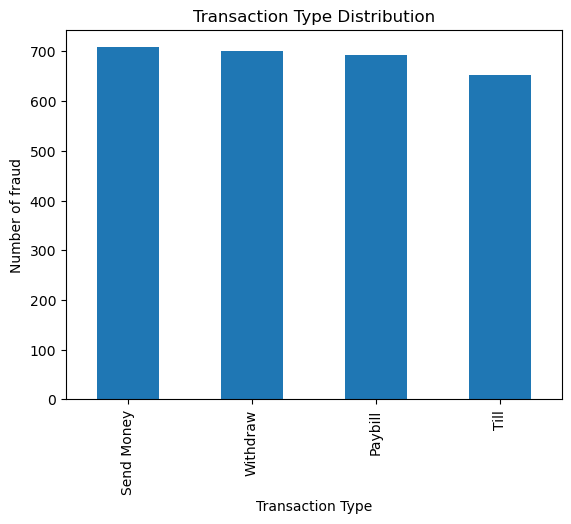

In [15]:
transaction_type = df[df["Fraudulent"] == "Yes"]["TransactionType"]
number = transaction_type.value_counts()#count the number of frauds per transaction_type
number.plot(kind="bar")
plt.xlabel("Transaction Type") # label the x_axis
plt.ylabel("Number of fraud") # label the y_axis
plt.title("Transaction Type Distribution") # give the chart a title
plt.show()

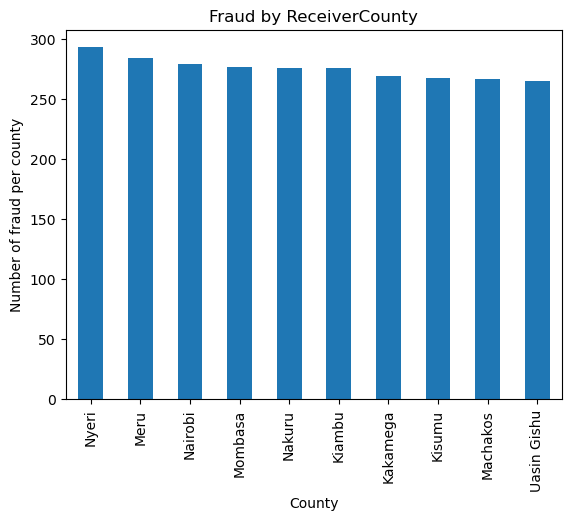

In [16]:
county = df[df["Fraudulent"] == "Yes"]["ReceiverCounty"]
number = county.value_counts()#count the number of frauds per county
number.plot(kind="bar")
plt.xlabel("County") # label the x_axis
plt.ylabel("Number of fraud per county") # label the y_axis
plt.title("Fraud by ReceiverCounty") # give the chart a title
plt.show()

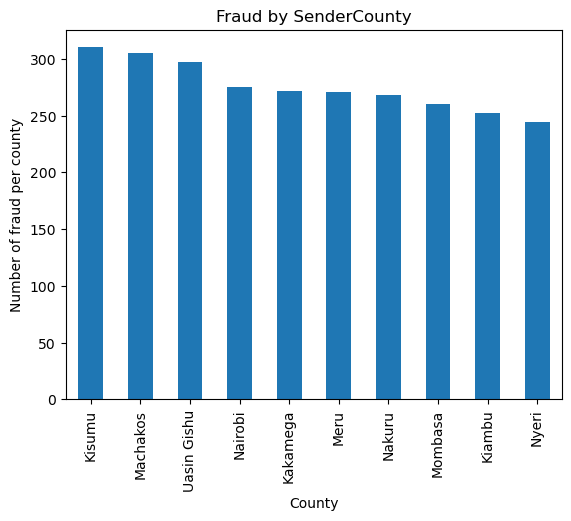

In [17]:
county = df[df["Fraudulent"] == "Yes"]["SenderCounty"]
number = county.value_counts()#count the number of frauds per county
number.plot(kind="bar")
plt.xlabel("County") # label the x_axis
plt.ylabel("Number of fraud per county") # label the y_axis
plt.title("Fraud by SenderCounty") # give the chart a title
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

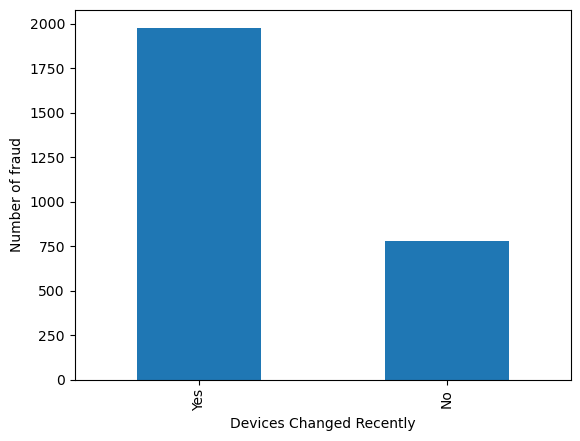

In [18]:
devices_change = df[df["Fraudulent"] == "Yes"]["DeviceChangedRecently"]
devices_change.value_counts().plot(kind ="bar")
plt.xlabel("Devices Changed Recently")
plt.ylabel("Number of fraud")
plt.show
#this shows that users who recently changed devices experience more fraud

In [19]:
Failed_pin = df[df["Fraudulent"] == "Yes"]["FailedPinAttempts"]
Failed_pin.value_counts()
#users with many failed PIN attempts experience more fraud

FailedPinAttempts
7    426
4    417
3    407
5    401
6    372
8    362
0    132
2    121
1    116
Name: count, dtype: int64

In [20]:
location = df[df["Fraudulent"] == "Yes"]["NewLocationLogin"]
location.value_counts()
#new-location logins have higher fraud rates

NewLocationLogin
Yes    1959
No      795
Name: count, dtype: int64

In [21]:
amount  = df[df["Fraudulent"] == "Yes"]["Amount"]
above = amount[amount > 100000]
below = amount[amount <= 100000]
print("Above 100000:", above.count())
print("Below or equal 100000:", below.count())
#transactions above KES 100,000 are more risky

Above 100000: 2294
Below or equal 100000: 460


In [23]:
#encoding categorical values
from sklearn.preprocessing import LabelEncoder
encoders = {}
df_copy = df.copy()
for col in categorical_df:
    if col != "Fraudulent":
        enc = LabelEncoder()
        df_copy[col] = enc.fit_transform(df_copy[col])
        encoders[col] = enc

In [24]:
#definig the x and y values
X = df_copy.drop(columns=["Fraudulent","TransactionID"])
y = df_copy["Fraudulent"]

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state = 42)
model = RandomForestClassifier()
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
predictions = model.predict(X_test)
predictions

array(['No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
       'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No',
       'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes',
       'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes',
       'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No',
       'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No',

In [27]:
#find the accuracy of the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,predictions)
accuracy

0.992

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[465   2]
 [  6 527]]


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

          No       0.99      1.00      0.99       467
         Yes       1.00      0.99      0.99       533

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [30]:
import pandas as pd
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)
print(importance)

                    Feature  Importance
7     DeviceChangedRecently    0.287777
8          NewLocationLogin    0.280318
9         FailedPinAttempts    0.277844
0                    Amount    0.047004
6   TransactionsLast24Hours    0.032960
5          AccountAgeMonths    0.027311
3                 TimeOfDay    0.015046
2            ReceiverCounty    0.011587
1              SenderCounty    0.011090
4           TransactionType    0.005962
10                IsWeekend    0.003102


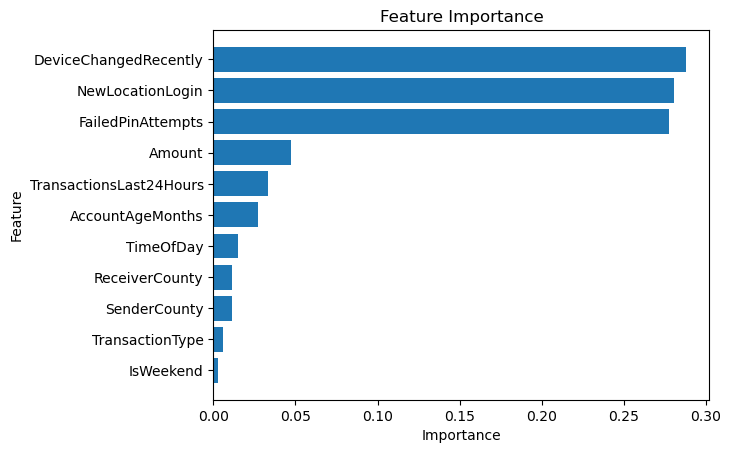

In [31]:
import matplotlib.pyplot as plt
importance = importance.sort_values('Importance', ascending=True)
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [32]:
#  These factors are the strongest indicators of fraud :
# FailedPinAttempts  ,
# DeviceChangedRecently  ,
# NewLocationLogin

In [39]:
new_data = pd.DataFrame([{
    "TransactionID":"TXN005000",
    "Amount": 250000,
    "SenderCounty": "Nairobi",
    "ReceiverCounty": "Kisumu",
    "TimeOfDay": 23,
    "TransactionType": "Send Money",
    "AccountAgeMonths": 1,
    "TransactionsLast24Hours": 15,
    "DeviceChangedRecently": "Yes",
    "NewLocationLogin": "Yes",
    "FailedPinAttempts": 5,
    "IsWeekend": "Yes"
}])

In [40]:
for col in categorical_df:
    if col != "Fraudulent":
        new_data[col] = encoders[col].transform(new_data[col])

In [41]:
prediction = model.predict(new_data[X.columns])
print(prediction)

['Yes']
